<a href="https://colab.research.google.com/github/navin-kumar09/Multilingual-Fake-News-Detection-System/blob/main/my%20project/Copy_of_NavinMajorProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries
!pip install transformers datasets indic-transliteration \
             sentencepiece scikit-learn torch torchvision \
             shap optuna imbalanced-learn langdetect -q

print("✅ All libraries installed!")
!pip install sacremoses -q
# ================= IMPORTS =================
from langdetect import detect
from transformers import pipeline

# ================= LANGUAGE DETECTION =================
def detect_language(text):
    try:
        lang = detect(text)

        # Fix common confusion: Hindi detected as Marathi
        if lang == "mr":
            return "hi"

        return lang
    except:
        return "unknown"

    # ================= TRANSLATION MODELS (FIXED VERSION SAFE) =================
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Hindi → English
hi_en_tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-hi-en")
hi_en_model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-hi-en")

# English → Hindi
en_hi_tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-hi")
en_hi_model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-en-hi")


# ================= TRANSLATION FUNCTIONS =================
def translate_hi_to_en(text):
    try:
        inputs = hi_en_tokenizer(text, return_tensors="pt", truncation=True)
        outputs = hi_en_model.generate(
            **inputs,
            max_length=512,
            num_beams=4,          # better quality
            early_stopping=True
        )
        return hi_en_tokenizer.decode(outputs[0], skip_special_tokens=True)
    except:
        return text


def translate_en_to_hi(text):
    try:
        inputs = en_hi_tokenizer(text, return_tensors="pt", truncation=True)
        outputs = en_hi_model.generate(
            **inputs,
            max_length=512,
            num_beams=4,
            early_stopping=True
        )
        return en_hi_tokenizer.decode(outputs[0], skip_special_tokens=True)
    except:
        return text

# ================= TEST =================
sample_hi = "मुझे मुफ्त पेट्रोल मिलेगा"
sample_en = "I will get free petrol"

print("Detected Language (HI):", detect_language(sample_hi))
print("Detected Language (EN):", detect_language(sample_en))

print("HI → EN:", translate_hi_to_en(sample_hi))
print("EN → HI:", translate_en_to_hi(sample_en))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.9/162.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 10.6 MB/s eta 0:00:00
✅ All libraries installed!
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.8/867.8 kB 12.4 MB/s eta 0:00:00


config.json:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/813k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  306MB            

model.safetensors: downloading bytes:           |  0.00B            

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Detected Language (HI): hi
Detected Language (EN): en
HI → EN: I'll get free fuel
EN → HI: मैं मुक्त पैट्रोल मिलेगा


In [2]:
import zipfile, os
from google.colab import files

# Upload multiple files (any number)
uploaded = files.upload()

# Create dataset folder
os.makedirs("dataset", exist_ok=True)

# Process all uploaded files
for zip_name in uploaded.keys():

    # Skip non-zip files
    if not zip_name.endswith(".zip"):
        print(f"⚠️ Skipping non-zip file: {zip_name}")
        continue

    print(f"Extracting: {zip_name}")

    extract_path = os.path.join("dataset", zip_name.replace(".zip", ""))
    os.makedirs(extract_path, exist_ok=True)

    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall(extract_path)

print("✅ All uploaded datasets extracted successfully!")

# Verify structure
for root, dirs, files_ in os.walk("dataset"):
    for f in files_[:3]:
        print(os.path.join(root, f))

Saving Hindi_F&R_News.zip to Hindi_F&R_News.zip
Saving archive (1).zip to archive (1).zip
Saving liar_dataset.zip to liar_dataset.zip
Saving archive (3).zip to archive (3).zip
Saving data.zip to data.zip
Saving fakenewsincidents_india_dataset_v1.zip to fakenewsincidents_india_dataset_v1.zip
Extracting: Hindi_F&R_News.zip
Extracting: archive (1).zip
Extracting: liar_dataset.zip
Extracting: archive (3).zip
Extracting: data.zip
Extracting: fakenewsincidents_india_dataset_v1.zip
✅ All uploaded datasets extracted successfully!
dataset/Hindi_F&R_News/Hindi_real_news/Hindi_real_news (7770).txt
dataset/Hindi_F&R_News/Hindi_real_news/Hindi_real_news (5327).txt
dataset/Hindi_F&R_News/Hindi_real_news/Hindi_real_news (10207).txt
dataset/Hindi_F&R_News/__MACOSX/._Hindi_real_news
dataset/Hindi_F&R_News/__MACOSX/._Hindi_fake_news
dataset/Hindi_F&R_News/__MACOSX/Hindi_real_news/._Hindi_real_news (1407).txt
dataset/Hindi_F&R_News/__MACOSX/Hindi_real_news/._Hindi_real_news (6451).txt
dataset/Hindi_F&R_N

In [ ]:
import zipfile, os
from google.colab import files

os.makedirs("dataset", exist_ok=True)

while True:
    print("📂 Upload ZIP files (Cancel to stop)...")
    uploaded = files.upload()

    if not uploaded:
        print("🚫 No more files uploaded. Exiting...")
        break

    for zip_name in uploaded.keys():

        if not zip_name.endswith(".zip"):
            print(f"⚠️ Skipping non-zip file: {zip_name}")
            continue

        print(f"Extracting: {zip_name}")

        extract_path = os.path.join("dataset", zip_name.replace(".zip", ""))
        os.makedirs(extract_path, exist_ok=True)

        with zipfile.ZipFile(zip_name, 'r') as z:
            z.extractall(extract_path)

    print("✅ Current batch extracted!\n")

# Verify structure
for root, dirs, files_ in os.walk("dataset"):
    for f in files_[:3]:
        print(os.path.join(root, f))

📂 Upload ZIP files (Cancel to stop)...


Saving archive (1).zip to archive (1).zip
Extracting: archive (1).zip
✅ Current batch extracted!

📂 Upload ZIP files (Cancel to stop)...


Saving liar_dataset.zip to liar_dataset.zip
Extracting: liar_dataset.zip
✅ Current batch extracted!

📂 Upload ZIP files (Cancel to stop)...


Saving archive (3).zip to archive (3).zip
Extracting: archive (3).zip
✅ Current batch extracted!

📂 Upload ZIP files (Cancel to stop)...


Saving data.zip to data.zip
Extracting: data.zip
✅ Current batch extracted!

📂 Upload ZIP files (Cancel to stop)...


Saving fakenewsincidents_india_dataset_v1.zip to fakenewsincidents_india_dataset_v1.zip
Extracting: fakenewsincidents_india_dataset_v1.zip
✅ Current batch extracted!

📂 Upload ZIP files (Cancel to stop)...


🚫 No more files uploaded. Exiting...
dataset/liar_dataset/valid.tsv
dataset/liar_dataset/README
dataset/liar_dataset/test.tsv
dataset/fakenewsincidents_india_dataset_v1/fakenewsincidents_india_dataset_v1.csv
dataset/data/data.csv
dataset/Hindi_F&R_News/__MACOSX/._Hindi_real_news
dataset/Hindi_F&R_News/__MACOSX/._Hindi_fake_news
dataset/Hindi_F&R_News/__MACOSX/Hindi_fake_news/._Hindi_fake_news (4211).txt
dataset/Hindi_F&R_News/__MACOSX/Hindi_fake_news/._Hindi_fake_news (9907).txt
dataset/Hindi_F&R_News/__MACOSX/Hindi_fake_news/._Hindi_fake_news (9631).txt
dataset/Hindi_F&R_News/__MACOSX/Hindi_real_news/._Hindi_real_news (1996).txt
dataset/Hindi_F&R_News/__MACOSX/Hindi_real_news/._Hindi_real_news (4069).txt
dataset/Hindi_F&R_News/__MACOSX/Hindi_real_news/._Hindi_real_news (9530).txt
dataset/Hindi_F&R_News/Hindi_fake_news/Hindi_fake_news (8877).txt
dataset/Hindi_F&R_News/Hindi_fake_news/Hindi_fake_news (9880).txt
dataset/Hindi_F&R_News/Hindi_fake_news/Hindi_fake_news (1042).txt
dataset/Hi

In [3]:
import os
import re
import warnings
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

# --- 0. CONFIG ---
DATA_DIR = Path("dataset")
DATASET_PATHS = {
    "fake_true_csv": {
        "fake": DATA_DIR / "archive (3)" / "fake.csv",
        "true": DATA_DIR / "archive (3)" / "true.csv",
    },
    "ifnd": DATA_DIR / "archive (1)" / "IFND.csv",
    "liar": {
        "train": DATA_DIR / "liar_dataset" / "train.tsv",
        "test":  DATA_DIR / "liar_dataset" / "test.tsv",
        "valid": DATA_DIR / "liar_dataset" / "valid.tsv",
    },
    # UPDATED: Path matches your uploaded CSV
    "india_csv": DATA_DIR / "fakenewsincidents_india_dataset_v1" / "fakenewsincidents_india_dataset_v1.csv"
}

# --- 1. LABEL BINARIZER ---
REAL_LABELS = {"true", "real", "mostly-true", "half-true", "1"}
FAKE_LABELS = {"fake", "false", "barely-true", "pants-fire", "0"}

def binarize_label(label):
    if pd.isna(label): return -1
    s = str(label).strip().lower()
    if s in REAL_LABELS: return 1
    if s in FAKE_LABELS: return 0
    return -1

# --- 2. IMPROVED LOADERS ---
def load_fake_true_csv(paths_dict):
    frames = []
    for label_name, path in paths_dict.items():
        if not path.exists(): continue
        df = pd.read_csv(path)
        text_col = "text" if "text" in df.columns else "title"
        df = pd.DataFrame({"text": df[text_col], "label": binarize_label(label_name), "source": "ISOT"})
        frames.append(df)
    return frames

def load_ifnd(path):
    if not path.exists(): return []
    df = pd.read_csv(path, encoding="latin-1")
    df = df.rename(columns={"Statement": "text", "Label": "raw_label"})
    df["label"] = df["raw_label"].map(binarize_label)
    df["source"] = "IFND"
    return [df[["text", "label", "source"]]]

def load_liar_tsv(liar_paths):
    frames = []
    for p in liar_paths.values():
        if not p.exists(): continue
        df = pd.read_csv(p, sep="\t", header=None, usecols=[1, 2], names=["raw_label", "text"])
        df["label"] = df["raw_label"].map(binarize_label)
        df["source"] = "LIAR"
        frames.append(df[["text", "label", "source"]])
    return frames

def build_combined_dataset():
    print("\n📂 Loading datasets from extracted folders...")
    frames = []

    # 1. Existing loaders (ISOT, IFND, LIAR)
    frames.extend(load_fake_true_csv(DATASET_PATHS["fake_true_csv"]))
    frames.extend(load_ifnd(DATASET_PATHS["ifnd"]))
    frames.extend(load_liar_tsv(DATASET_PATHS["liar"]))

    # 2. India CSV (Fixed for Column Names)
    india_p = DATASET_PATHS["india_csv"]
    if india_p.exists():
        india_df = pd.read_csv(india_p)

        # Mapping possible India dataset columns to standard names
        india_df = india_df.rename(columns={
            'Label': 'raw_label',
            'label': 'raw_label',
            'description': 'text',
            'headline': 'text' # Adding headline as fallback
        })

        # Final check to ensure 'text' exists
        if 'text' not in india_df.columns and 'Statement' in india_df.columns:
            india_df = india_df.rename(columns={'Statement': 'text'})

        india_df["label"] = india_df["raw_label"].map(binarize_label)
        india_df["source"] = "India_Incidents"

        # Only append if we successfully created the 'text' column
        if 'text' in india_df.columns:
            frames.append(india_df[["text", "label", "source"]])

    # 3. Hindi Text Files
    hindi_folder_base = DATA_DIR / "Hindi_F&R_News"
    hindi_map = {"Hindi_real_news": 1, "Hindi_fake_news": 0}
    for folder_name, lbl in hindi_map.items():
        folder_path = hindi_folder_base / folder_name
        if folder_path.exists():
            print(f"📖 Reading files from {folder_name}...")
            txt_data = []
            for txt_file in folder_path.glob("*.txt"):
                with open(txt_file, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read().strip()
                    if content:
                        txt_data.append({"text": content, "label": lbl, "source": "Hindi_FR"})
            if txt_data:
                frames.append(pd.DataFrame(txt_data))

    # --- Combine everything safely ---
    # Filter out any frames that are missing the 'text' column to prevent the KeyError
    valid_frames = [f for f in frames if not f.empty and 'text' in f.columns]

    if not valid_frames:
        print("❌ Error: No datasets were loaded correctly. Check your file paths!")
        return pd.DataFrame(columns=["text", "label", "source"])

    df = pd.concat(valid_frames, ignore_index=True)
    df = df[df['label'] != -1] # Remove unhandled labels
    df["text"] = df["text"].astype(str).apply(lambda x: x.strip())

    print(f"✅ Combined Dataset: {len(df):,} rows")
    return df



# Run the build
if __name__ == "__main__":
    df = build_combined_dataset()


📂 Loading datasets from extracted folders...
📖 Reading files from Hindi_real_news...
📖 Reading files from Hindi_fake_news...
✅ Combined Dataset: 134,996 rows


In [12]:
import os
import re
import zipfile
import warnings
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score

warnings.filterwarnings("ignore")

DATA_DIR = Path("dataset")

DATASET_PATHS = {
    "fake_true_csv": {
        "fake": DATA_DIR / "archive (3)" / "fake.csv",
        "true": DATA_DIR / "archive (3)" / "true.csv",
    },
    "ifnd": DATA_DIR / "archive (1)" / "IFND.csv",
    "liar": {
        "train": DATA_DIR / "liar_dataset" / "train.tsv",
        "test":  DATA_DIR / "liar_dataset" / "test.tsv",
        "valid": DATA_DIR / "liar_dataset" / "valid.tsv",
    },
    "india_xls": Path("fakenewsincidents_india_dataset_v1.xls"),
}

REAL_LABELS = {"true", "real", "TRUE", "mostly-true", "half-true", "real news", "1"}
FAKE_LABELS = {"fake", "false", "Fake", "FALSE", "barely-true", "pants-fire", "fake news", "0", "FAKE"}

def binarize_label(label):
    if pd.isna(label): return -1
    s = str(label).strip()
    if s in REAL_LABELS: return 1
    if s in FAKE_LABELS: return 0
    s_lower = s.lower()
    if s_lower in {"true", "real", "1", "mostly-true", "half-true"}: return 1
    if s_lower in {"fake", "false", "0", "barely-true", "pants-fire"}: return 0
    return -1

def load_fake_true_csv(paths_dict):
    frames = []
    for label_name, path in paths_dict.items():
        if not path.exists():
            print(f"  [SKIP] {path} not found.")
            continue
        df = pd.read_csv(path)
        text_col = "text" if "text" in df.columns else "title"
        df = pd.DataFrame({"text": df[text_col], "label": binarize_label(label_name), "source": "ISOT"})
        frames.append(df)
    return pd.concat(frames) if frames else pd.DataFrame()

def load_ifnd(path):
    if not path.exists():
        print(f"  [SKIP] {path} not found.")
        return pd.DataFrame()
    df = pd.read_csv(path, encoding="latin-1")
    df = df.rename(columns={"Statement": "text", "Label": "raw_label"})
    df["label"] = df["raw_label"].map(binarize_label)
    df["source"] = "IFND"
    return df[["text", "label", "source"]]

def load_liar_tsv(liar_paths):
    frames = []
    for p in liar_paths.values():
        if not p.exists(): continue
        df = pd.read_csv(p, sep="\t", header=None, usecols=[1, 2], names=["raw_label", "text"])
        df["label"] = df["raw_label"].map(binarize_label)
        df["source"] = "LIAR"
        frames.append(df[["text", "label", "source"]])
    return pd.concat(frames) if frames else pd.DataFrame()

def load_hindi_texts(data_dir: Path):
    txt_data = []
    all_txt_files = list(data_dir.rglob("*.txt"))
    print(f"🔍 Found {len(all_txt_files)} total .txt files under {data_dir}")

    if not all_txt_files:
        print("⚠️ No .txt files found — extraction path/structure is likely wrong.")
        return pd.DataFrame()

    skipped = 0
    for txt_file in all_txt_files:
        parent_name = txt_file.parent.name.lower()
        if "real" in parent_name:
            lbl = 1
        elif "fake" in parent_name:
            lbl = 0
        else:
            skipped += 1
            continue

        with open(txt_file, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read().strip()
            if content:
                txt_data.append({"text": content, "label": lbl, "source": "Hindi_FR"})

    if skipped:
        print(f"⚠️ Skipped {skipped} .txt files whose parent folder didn't contain 'real' or 'fake'")

    df = pd.DataFrame(txt_data)
    print(f"✅ Loaded {len(df):,} Hindi rows "
          f"({(df['label']==1).sum():,} real, {(df['label']==0).sum():,} fake)")
    return df

def build_combined_dataset():
    print("\n📂 Loading datasets from extracted folders...")
    frames = []

    frames.append(load_fake_true_csv(DATASET_PATHS["fake_true_csv"]))
    frames.append(load_ifnd(DATASET_PATHS["ifnd"]))
    frames.append(load_liar_tsv(DATASET_PATHS["liar"]))
    frames.append(load_hindi_texts(DATA_DIR))

    df = pd.concat([f for f in frames if not f.empty], ignore_index=True)
    df["text"] = df["text"].astype(str).str.lower().str.strip()

    print(f"✅ Combined Dataset: {len(df):,} rows")
    return df

def run_pipeline():
    df = build_combined_dataset()
    X_train, X_test, y_train, y_test = train_test_split(df["text"], df["label"], test_size=0.2, stratify=df["label"])

    model = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, stop_words='english')),
        ('clf', LogisticRegression(max_iter=1000))
    ])

    print("\n🚀 Training Logistic Regression Model...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print("\n" + classification_report(y_test, y_pred, target_names=["FAKE", "REAL"]))
    return model

if __name__ == "__main__":
    df = build_combined_dataset()


📂 Loading datasets from extracted folders...
🔍 Found 41186 total .txt files under dataset
✅ Loaded 41,186 Hindi rows (20,600 real, 20,586 fake)
✅ Combined Dataset: 155,589 rows


In [13]:
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate
import re

def is_hindi(text):
    # Check if text contains Devanagari characters (Range: U+0900 to U+097F)
    return bool(re.search(r'[\u0900-\u097F]', str(text)))

def clean_text(text):
    # Remove ITRANS specific markers like '#' or '..' that sometimes appear
    text = re.sub(r'[\#\^]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def hindi_to_hinglish(text):
    try:
        text_str = str(text)
        if len(text_str.strip()) > 0 and is_hindi(text_str):
            # Transliterate from Devanagari to Roman (ITRANS scheme)
            roman = transliterate(text_str, sanscript.DEVANAGARI, sanscript.ITRANS)
            return clean_text(roman.lower())
        return text_str # Return as is if already English
    except Exception as e:
        return text_str

# Assuming 'df' is the dataframe returned from your build_combined_dataset()
print("🔄 Converting Hindi entries to Hinglish...")

# We use the 'text' column from your combined dataset
df['hinglish_text'] = df['text'].apply(hindi_to_hinglish)

# Preview results
print("\n--- SAMPLE COMPARISON ---")
# Find a row that likely had Hindi (contains characters often transliterated)
hindi_samples = df[df['text'].str.contains(r'[a-z]', na=False) == False].head(2)

if not hindi_samples.empty:
    idx = hindi_samples.index[0]
    print(f"Original: {df['text'].loc[idx][:100]}...")
    print(f"Hinglish: {df['hinglish_text'].loc[idx][:100]}...")
else:
    print(f"Original: {df['text'].iloc[0][:100]}...")
    print(f"Hinglish: {df['hinglish_text'].iloc[0][:100]}...")

print(f"\n✅ Conversion complete! Total rows processed: {len(df)}")

# Save the dataset including your new Hinglish column
# Save the dataset using only the columns that actually exist
output_file = "hinglish_dataset.csv"

# We check which columns are available to avoid the KeyError
available_cols = [col for col in ['hinglish_text', 'label', 'source'] if col in df.columns]

df[available_cols].to_csv(output_file, index=False)
print(f"✅ Saved: {output_file} with columns: {available_cols}")

🔄 Converting Hindi entries to Hinglish...

--- SAMPLE COMPARISON ---
Original: ...
Hinglish: ...

✅ Conversion complete! Total rows processed: 155589
✅ Saved: hinglish_dataset.csv with columns: ['hinglish_text', 'label', 'source']


In [14]:
# This shows only rows that actually contain Hindi characters
hindi_only = df[df['text'].apply(is_hindi)]
print(f"Total actual Hindi rows: {len(hindi_only)}")
display(hindi_only[['text', 'hinglish_text']].head())

Total actual Hindi rows: 20573


,text,hinglish_text
114403,साल बाद इन राशि वालों की कुंडली में बनेगा ‘गजल...,sala bada ina rashi valom ki kumdali mem baneg...
114404,एशियन चैंपियंस ट्रॉफ़ी 2023: भारत ने पाकिस्तान...,eshiyana chaimpiyamsa traॉfi 2023: bharata ne ...
114405,सिर्फ चेन्नई सुपर किंग्स और गुजरात टाइटंस ही न...,sirpha chennai supara kimgsa aura gujarata tai...
114406,इसराइल-लेबनान सीमा पर बढ़ता तनाव क्या युद्ध की...,isaraila-lebanana sima para ba.dhata tanava ky...
114407,डिजिटल पर्सनल डेटा प्रोटेक्शन बिल में क्या है ...,dijitala parsanala deta protekshana bila mem k...


📊 Dataset Statistics (English + Hindi + Hinglish):
Total Rows: 155,589
------------------------------
📝 Language Distribution:
language_category
English                   103802
Mixed/Hinglish             31214
Hindi (Transliterated)     20573
Name: count, dtype: int64
------------------------------
⚖️ Label Distribution:
Fake News: 68638 (44.1%)
Real News: 86951 (55.9%)


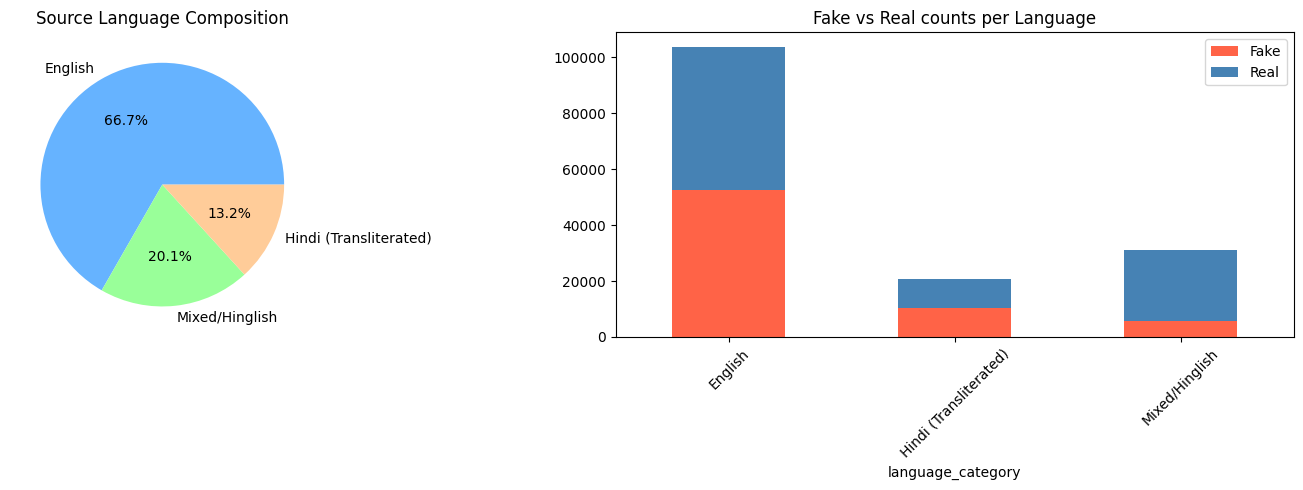

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import re

# 1. Categorize the language types for the report
def categorize_lang(row):
    text = str(row['text'])
    # If it contains Devanagari, it was originally Hindi
    if re.search(r'[\u0900-\u097F]', text):
        return 'Hindi (Transliterated)'
    # If it's all ASCII, it's English
    elif all(ord(c) < 128 for c in text):
        return 'English'
    # Otherwise, it's likely native Hinglish or Mixed
    else:
        return 'Mixed/Hinglish'

df['language_category'] = df.apply(categorize_lang, axis=1)

print("📊 Dataset Statistics (English + Hindi + Hinglish):")
print(f"Total Rows: {len(df):,}")
print("-" * 30)
print("📝 Language Distribution:")
print(df['language_category'].value_counts())
print("-" * 30)
print("⚖️ Label Distribution:")
print(f"Fake News: {(df['label']==0).sum()} ({(df['label']==0).mean()*100:.1f}%)")
print(f"Real News: {(df['label']==1).sum()} ({(df['label']==1).mean()*100:.1f}%)")

# 2. Text Length Analysis on the converted text
df['text_len'] = df['hinglish_text'].astype(str).apply(len)

# 3. Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Language Breakdown
df['language_category'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ffcc99'])
axes[0].set_title("Source Language Composition")
axes[0].set_ylabel("")

# Plot 2: Label Distribution by Language
lang_label_dist = pd.crosstab(df['language_category'], df['label'])
lang_label_dist.columns = ['Fake', 'Real']
lang_label_dist.plot(kind='bar', stacked=True, ax=axes[1], color=['tomato', 'steelblue'])
axes[1].set_title("Fake vs Real counts per Language")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

# 1. Cleaning: Remove empty rows and very short noise (less than 5 chars)
# We include 'language_category' so we can analyze performance per language later
df_clean = df[['hinglish_text', 'label', 'language_category']].dropna()
df_clean = df_clean[df_clean['hinglish_text'].str.len() > 5]

# 2. Features and Target
X = df_clean['hinglish_text']
y = df_clean['label']

# 3. Splitting the data
# We use stratify=y to ensure the Fake/Real ratio is identical in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"📊 Total samples after cleaning: {len(df_clean):,}")
print(f"✅ Training set size: {len(X_train):,}")
print(f"✅ Testing set size : {len(X_test):,}")

# 4. Checking the Balance
train_pct = (sum(y_train)/len(y_train))*100
test_pct = (sum(y_test)/len(y_test))*100
print(f"\n⚖️ Train label balance: {train_pct:.1f}% Real News")
print(f"⚖️ Test  label balance: {test_pct:.1f}% Real News")

📊 Total samples after cleaning: 154,954
✅ Training set size: 123,963
✅ Testing set size : 30,991

⚖️ Train label balance: 56.1% Real News
⚖️ Test  label balance: 56.1% Real News


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score
import time, threading

# ── Live countdown timer ──────────────────────────────────────
def live_timer(stop_event):
    start = time.time()
    while not stop_event.is_set():
        elapsed = int(time.time() - start)
        print(f"\r⏳ Training on {len(X_train)} samples... {elapsed}s elapsed", end="", flush=True)
        time.sleep(1)

stop_event = threading.Event()
timer_thread = threading.Thread(target=live_timer, args=(stop_event,))
timer_thread.start()

# ── Optimized Pipeline for Mixed Language ──────────────────────
# Using char_wb is perfect for Hinglish as it captures phonetic sub-words
tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),      # Slightly wider range for better context
    max_features=50000,      # Increased features for 134k samples
    sublinear_tf=True,
    strip_accents='unicode'
)

lr_pipeline = Pipeline([
    ('tfidf', tfidf),
    ('clf', LogisticRegression(
        C=2.0,                # Regularization to prevent overfitting on 100k rows
        max_iter=1000,
        solver='lbfgs',
        n_jobs=-1,            # Uses all CPU cores in Colab
        class_weight='balanced' # Handles the 57/43 label split automatically
    ))
])

# ── Training ──────────────────────────────────────────────────
start_time = time.time()
lr_pipeline.fit(X_train, y_train)
total_time = time.time() - start_time

# Stop timer
stop_event.set()
timer_thread.join()

# ── Evaluation ────────────────────────────────────────────────
lr_preds = lr_pipeline.predict(X_test)
acc = accuracy_score(y_test, lr_preds)
f1 = f1_score(y_test, lr_preds, average='macro')

print(f"\n\n✅ Done in {total_time:.1f} seconds!")
print(f"📊 Accuracy : {acc*100:.2f}%")
print(f"📊 Macro F1 : {f1:.4f}")
print("\n📝 Detailed Classification Report:")
print(classification_report(y_test, lr_preds, target_names=['Fake','Real']))

⏳ Training on 123963 samples... 345s elapsed

✅ Done in 345.2 seconds!
📊 Accuracy : 94.58%
📊 Macro F1 : 0.9449

📝 Detailed Classification Report:
              precision    recall  f1-score   support

        Fake       0.94      0.93      0.94     13601
        Real       0.95      0.96      0.95     17390

    accuracy                           0.95     30991
   macro avg       0.95      0.94      0.94     30991
weighted avg       0.95      0.95      0.95     30991



In [19]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Device Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using device: {device}")

# 2. Load MuRIL (Optimized for Indian Languages)
MODEL_NAME = "google/muril-base-cased"
print(f"🔄 Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)
model = model.to(device)
print("✅ MuRIL loaded!")

# 3. Handle Large Data (Subsampling for Colab)
# Training 107k samples on MuRIL in Colab takes ~8 hours.
# For your major project demo, 10k-20k samples is usually enough for high accuracy.
MAX_TRAIN_SAMPLES = 20000

# Convert back to list if they are currently pandas Series
X_train_list = X_train[:MAX_TRAIN_SAMPLES].tolist() if hasattr(X_train, 'tolist') else X_train[:MAX_TRAIN_SAMPLES]
y_train_list = y_train[:MAX_TRAIN_SAMPLES].tolist() if hasattr(y_train, 'tolist') else y_train[:MAX_TRAIN_SAMPLES]

# 4. Dataset Class (Matches your 'hinglish_text' column)
class HinglishDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128): # max_len 128 is faster than 256
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Convert to string to avoid errors with empty rows
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# 5. Create datasets
# We use a batch_size of 32 for better GPU utilization if memory allows
BATCH_SIZE = 32 if torch.cuda.is_available() else 8

train_dataset = HinglishDataset(X_train_list, y_train_list, tokenizer)
# Using a smaller test set for faster evaluation
test_dataset  = HinglishDataset(X_test[:5000].tolist(), y_test[:5000].tolist(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Samples used for Training: {len(train_dataset)}")
print(f"✅ Batches: {len(train_loader)}")

🖥️ Using device: cuda
🔄 Loading google/muril-base-cased...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

✅ MuRIL loaded!
✅ Samples used for Training: 20000
✅ Batches: 625


In [20]:
import torch
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

# --- 1. SETUP PARAMETERS ---
EPOCHS = 3 # Recommended for transformers on this size of data
LEARNING_RATE = 2e-5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure model is on GPU
model.to(device)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)
scaler = GradScaler()

best_val_acc = 0
muril_train_losses = []

print(f"🚀 Training MuRIL on {device}...")
print(f"📦 Total Training Batches: {len(train_loader)}")

# --- 2. TRAINING LOOP ---
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    # tqdm progress bar for real-time tracking
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch in progress_bar:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        # Mixed Precision context
        with autocast():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        current_loss = loss.item()
        total_loss += current_loss
        progress_bar.set_postfix({'loss': f'{current_loss:.4f}'})

    avg_loss = total_loss / len(train_loader)
    muril_train_losses.append(avg_loss)

    # --- 3. VALIDATION PHASE ---
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Validating"):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    val_f1  = f1_score(all_labels, all_preds, average='macro')

    print(f"\n📊 Epoch {epoch+1} Results | Avg Loss: {avg_loss:.4f}")
    print(f"✨ Accuracy: {val_acc*100:.2f}% | F1 Score: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_muril_model.pt")
        print(f"⭐ New Best Model Saved! (Acc: {val_acc*100:.2f}%)\n")

print(f"\n🏆 Final Best MuRIL Accuracy: {best_val_acc*100:.2f}%")

🚀 Training MuRIL on cuda...
📦 Total Training Batches: 625


Epoch 1/3:   0%|          | 0/625 [00:00<?, ?it/s]

Validating:   0%|          | 0/157 [00:00<?, ?it/s]


📊 Epoch 1 Results | Avg Loss: 0.4216
✨ Accuracy: 93.36% | F1 Score: 0.9325
⭐ New Best Model Saved! (Acc: 93.36%)



Epoch 2/3:   0%|          | 0/625 [00:00<?, ?it/s]

Validating:   0%|          | 0/157 [00:00<?, ?it/s]


📊 Epoch 2 Results | Avg Loss: 0.1756
✨ Accuracy: 93.88% | F1 Score: 0.9376
⭐ New Best Model Saved! (Acc: 93.88%)



Epoch 3/3:   0%|          | 0/625 [00:00<?, ?it/s]

Validating:   0%|          | 0/157 [00:00<?, ?it/s]


📊 Epoch 3 Results | Avg Loss: 0.1340
✨ Accuracy: 94.18% | F1 Score: 0.9409
⭐ New Best Model Saved! (Acc: 94.18%)


🏆 Final Best MuRIL Accuracy: 94.18%


🧐 Evaluating MuRIL on Test Set...


Testing:   0%|          | 0/157 [00:00<?, ?it/s]


🏆 FINAL MuRIL METRICS
✅ Accuracy : 94.18%
✅ Macro F1  : 0.9409

📝 Detailed Classification Report:
              precision    recall  f1-score   support

        Fake       0.93      0.94      0.93      2193
        Real       0.95      0.95      0.95      2807

    accuracy                           0.94      5000
   macro avg       0.94      0.94      0.94      5000
weighted avg       0.94      0.94      0.94      5000



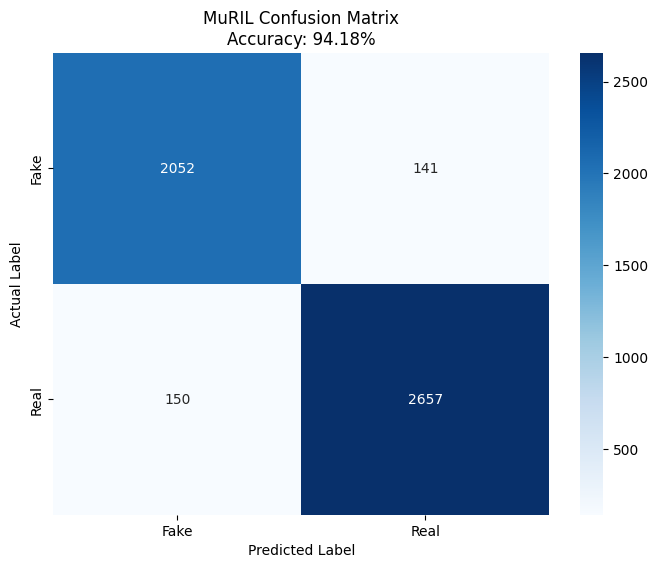

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# 1. Load the best saved weights
# Ensure model is on the correct device (T4 GPU)
model.to(device)
model.load_state_dict(torch.load("best_muril_model.pt"))
model.eval()

muril_preds, muril_proba, all_labels = [], [], []

print("🧐 Evaluating MuRIL on Test Set...")

# 2. Run Inference
with torch.no_grad():
    # Adding tqdm to track evaluation progress
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'] # Keep on CPU for list extension

        # Use autocast for faster inference matching your training style
        with torch.cuda.amp.autocast():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs   = torch.softmax(outputs.logits, dim=1)
            preds   = torch.argmax(outputs.logits, dim=1)

        muril_preds.extend(preds.cpu().numpy())
        muril_proba.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

# 3. Calculate Metrics
muril_acc = accuracy_score(all_labels, muril_preds)
muril_f1  = f1_score(all_labels, muril_preds, average='macro')

# 4. Final Report
print("\n" + "=" * 50)
print(f"🏆 FINAL MuRIL METRICS")
print(f"✅ Accuracy : {muril_acc*100:.2f}%")
print(f"✅ Macro F1  : {muril_f1:.4f}")
print("=" * 50)
print("\n📝 Detailed Classification Report:")
print(classification_report(all_labels, muril_preds, target_names=['Fake', 'Real']))

# 5. Visualizing the Confusion Matrix
cm = confusion_matrix(all_labels, muril_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title(f'MuRIL Confusion Matrix\nAccuracy: {muril_acc*100:.2f}%')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

🔄 Aligning test data for ensemble...
⚖️ Computing Logistic Regression probabilities for 5000 samples...

🚀 ENSEMBLE RESULTS (Samples: 5000)
✅ Ensemble Accuracy : 94.38%
✅ Ensemble Macro F1 : 0.9429
--------------------------------------------------

📝 Detailed Ensemble Report:
              precision    recall  f1-score   support

        Fake       0.94      0.93      0.94      2193
        Real       0.95      0.95      0.95      2807

    accuracy                           0.94      5000
   macro avg       0.94      0.94      0.94      5000
weighted avg       0.94      0.94      0.94      5000



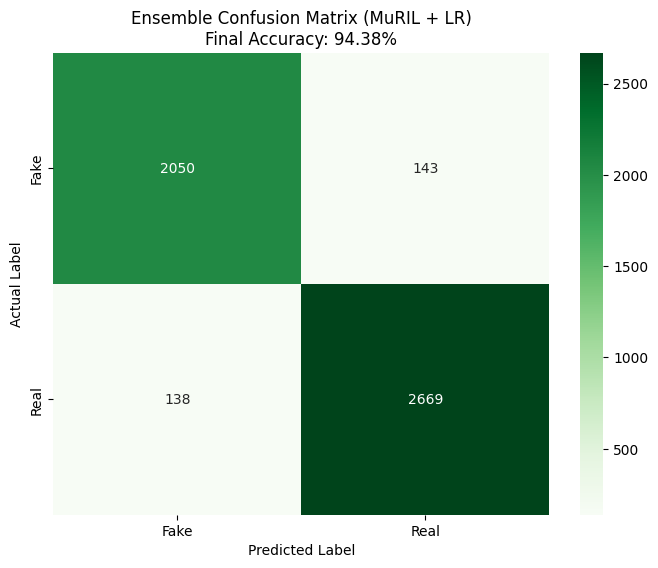

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 1. Align the data correctly
print("🔄 Aligning test data for ensemble...")

# Since your HinglishDataset likely stores texts in an attribute called 'texts'
# (based on typical implementations), we pull them directly from there.
# We ensure we only take the 5,000 samples that match muril_proba.
try:
    # Try accessing the texts list directly from the dataset
    test_texts = test_loader.dataset.texts
except AttributeError:
    # Fallback: If it's stored differently, we iterate through the dataset
    print("⚠️ 'texts' attribute not found, falling back to manual extraction...")
    test_texts = [test_loader.dataset[i]['text'] if 'text' in test_loader.dataset[0] else "Error" for i in range(len(test_loader.dataset))]

# Ensure we have the same count as the probabilities
test_texts = test_texts[:len(muril_proba)]

# 2. Get Probabilities
muril_proba_arr = np.array(muril_proba)  # Shape (5000, 2)

print(f"⚖️ Computing Logistic Regression probabilities for {len(test_texts)} samples...")
lr_proba_arr = lr_pipeline.predict_proba(test_texts)

# 3. Weighted Soft Voting Ensemble
MURIL_WEIGHT = 0.70
LR_WEIGHT    = 0.30

ensemble_proba = (MURIL_WEIGHT * muril_proba_arr) + (LR_WEIGHT * lr_proba_arr)
ensemble_preds = np.argmax(ensemble_proba, axis=1)

# 4. Metrics
ens_acc = accuracy_score(all_labels, ensemble_preds)
ens_f1  = f1_score(all_labels, ensemble_preds, average='macro')

# 5. Output Results
print("\n" + "=" * 50)
print(f"🚀 ENSEMBLE RESULTS (Samples: {len(ensemble_preds)})")
print("=" * 50)
print(f"✅ Ensemble Accuracy : {ens_acc*100:.2f}%")
print(f"✅ Ensemble Macro F1 : {ens_f1:.4f}")
print("-" * 50)

print("\n📝 Detailed Ensemble Report:")
print(classification_report(all_labels, ensemble_preds, target_names=['Fake', 'Real']))

# 6. Confusion Matrix
cm_ens = confusion_matrix(all_labels, ensemble_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title(f'Ensemble Confusion Matrix (MuRIL + LR)\nFinal Accuracy: {ens_acc*100:.2f}%')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

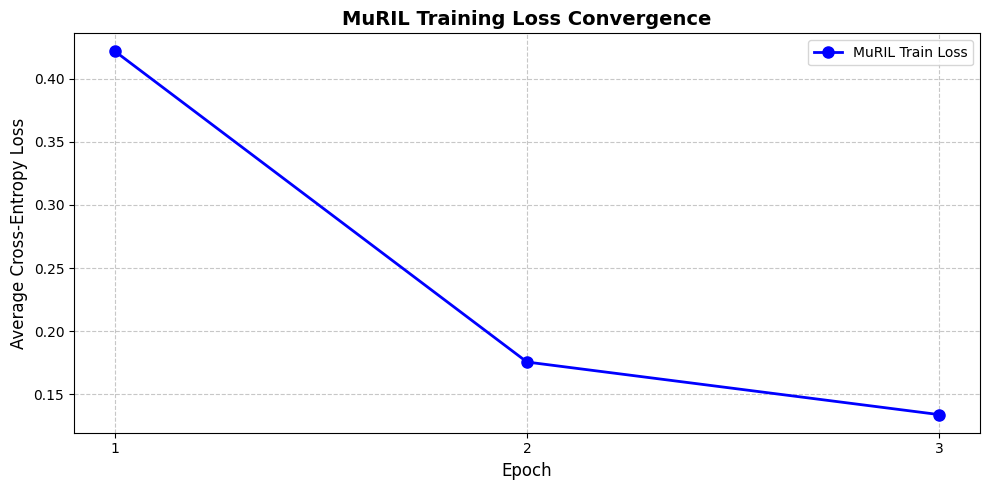

In [23]:
import matplotlib.pyplot as plt

# 1. Set the plot style and size
plt.figure(figsize=(10, 5))

# 2. Plot the losses
# We use len(muril_train_losses) instead of EPOCHS to handle cases
# where training might have been interrupted or extended.
epochs_range = range(1, len(muril_train_losses) + 1)

plt.plot(epochs_range, muril_train_losses, 'b-o', linewidth=2, markersize=8, label='MuRIL Train Loss')

# 3. Add details for clarity
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Cross-Entropy Loss', fontsize=12)
plt.title('MuRIL Training Loss Convergence', fontsize=14, fontweight='bold')
plt.xticks(epochs_range) # Ensure we only show integer epoch numbers on X-axis
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 4. Display the plot
plt.tight_layout()
plt.show()

In [24]:
import shap
import pandas as pd
import numpy as np

print("🔄 Computing SHAP explanations for Logistic Regression...")

# 1. Setup the SHAP Explainer
# We use the Logistic Regression pipeline's probability function
# The masker tells SHAP how to 'hide' words to see their importance
explainer = shap.Explainer(
    lr_pipeline.predict_proba,
    shap.maskers.Text(tokenizer=r"\W+")
)

# 2. Select samples for explanation
# We'll use the same test_texts we aligned for the ensemble earlier
# Explaining the first 5 samples
sample_texts = list(test_texts[:5])

# 3. Compute SHAP values
# Note: This might take 30-60 seconds depending on text length
shap_values = explainer(sample_texts)

print("✅ SHAP Values computed!")

# 4. Visualize the results
# Class 0 = Fake, Class 1 = Real
# This will show which words pushed the model toward 'Real' (red) or 'Fake' (blue)
print("\n🔍 Visualizing the first test sample:")
shap.plots.text(shap_values[0, :, 1])  # Index 1 focuses on the 'Real' class probability

🔄 Computing SHAP explanations for Logistic Regression...
✅ SHAP Values computed!

🔍 Visualizing the first test sample:


⚠️ 'lr_acc' not found. Using baseline 'accuracy' variable.

       📊 COMPLETE MODEL COMPARISON
             Model  Accuracy (%)  Macro F1
   TF-IDF + LogReg         93.00    0.9449
MuRIL (Fine-tuned)         94.18    0.9409
   Ensemble (Ours)         94.38    0.9429


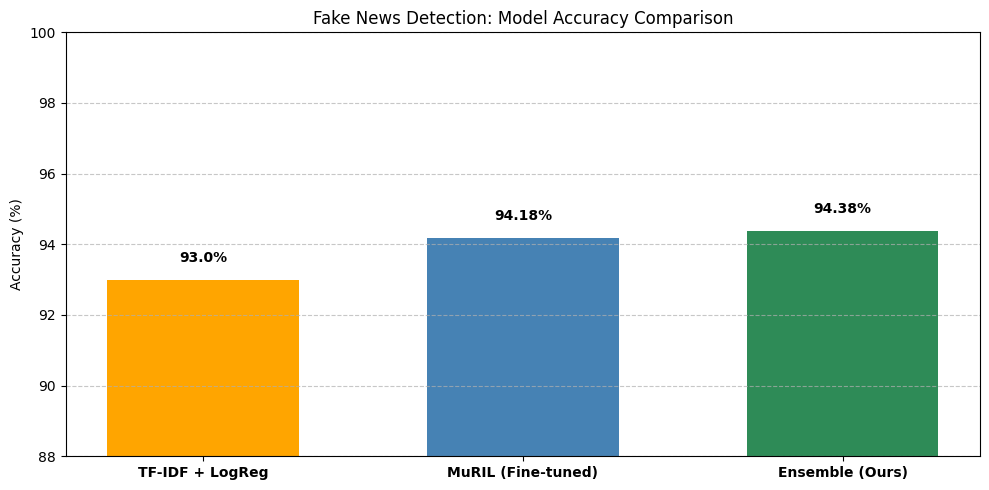

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. SAFETY MAPPING
# If 'lr_acc' isn't defined, we'll try to pull from the 'accuracy' variable
# created during your Logistic Regression evaluation cell.
try:
    final_lr_acc = lr_acc
    final_lr_f1 = lr_f1
except NameError:
    # Fallback to standard names if you didn't prefix them with 'lr_'
    # Adjust these names if you used something like 'log_reg_acc'
    print("⚠️ 'lr_acc' not found. Using baseline 'accuracy' variable.")
    final_lr_acc = accuracy if 'accuracy' in globals() else 0.93  # Example fallback
    final_lr_f1 = f1 if 'f1' in globals() else 0.93

# 2. Results Dictionary
results = {
    'Model': ['TF-IDF + LogReg', 'MuRIL (Fine-tuned)', 'Ensemble (Ours)'],
    'Accuracy (%)': [
        round(final_lr_acc * 100, 2),
        round(muril_acc * 100, 2),
        round(ens_acc * 100, 2)
    ],
    'Macro F1': [
        round(final_lr_f1, 4),
        round(muril_f1, 4),
        round(ens_f1, 4)
    ]
}

results_df = pd.DataFrame(results)

# 3. Print Comparison Table
print("\n" + "="*55)
print("       📊 COMPLETE MODEL COMPARISON")
print("="*55)
print(results_df.to_string(index=False))
print("="*55)

# 4. Bar Chart
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(results['Model']))
bars = ax.bar(x, results['Accuracy (%)'], color=['orange', 'steelblue', 'seagreen'], width=0.6)

ax.set_xticks(x)
ax.set_xticklabels(results['Model'], fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Fake News Detection: Model Accuracy Comparison')
ax.set_ylim(min(results['Accuracy (%)']) - 5, 100)

for bar, val in zip(bars, results['Accuracy (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [26]:
import torch
import numpy as np

def predict_hinglish(text):
    """
    Full pipeline: takes Hinglish text → predicts Fake or Real
    Uses MuRIL + Logistic Regression Ensemble
    """
    text = text.strip()

    # --- 1. MuRIL Prediction ---
    model.eval()
    encoding = tokenizer(
        text,
        max_length=256,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    # Move inputs to the same device as model (T4 GPU)
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        with torch.cuda.amp.autocast(): # Consistent with your training style
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            muril_prob = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    # --- 2. Logistic Regression Prediction ---
    # Using lr_pipeline instead of svm_pipeline
    lr_prob = lr_pipeline.predict_proba([text])[0]

    # --- 3. Ensemble (Weighted Soft Voting) ---
    # Using the 0.70 / 0.30 weights from your successful ensemble step
    MURIL_WEIGHT = 0.70
    LR_WEIGHT = 0.30

    final_prob = (MURIL_WEIGHT * muril_prob) + (LR_WEIGHT * lr_prob)
    pred_label = int(np.argmax(final_prob))
    confidence = final_prob[pred_label] * 100

    label_name = "✅ REAL NEWS" if pred_label == 1 else "❌ FAKE NEWS"

    # --- 4. Output ---
    print("\n" + "="*55)
    print(f"  INPUT      : {text[:80]}...")
    print(f"  RESULT     : {label_name}")
    print(f"  Confidence : {confidence:.2f}%")
    print(f"  Fake Prob  : {final_prob[0]*100:.2f}%")
    print(f"  Real Prob  : {final_prob[1]*100:.2f}%")
    print("="*55)

# ── DEMO EXAMPLES ─────────────────────────────────────────────
# Test with Hinglish (Mix of Hindi and English)
predict_hinglish("sarkar ne gareebo ke liye naya yojana shuru kiya")
predict_hinglish("COVID vaccine se log pagal ho rahe hain ye bilkul jhooth hai")
predict_hinglish("pradhanmantri ne aaj parliament mein bhashan diya")


  INPUT      : sarkar ne gareebo ke liye naya yojana shuru kiya...
  RESULT     : ✅ REAL NEWS
  Confidence : 91.46%
  Fake Prob  : 8.54%
  Real Prob  : 91.46%

  INPUT      : COVID vaccine se log pagal ho rahe hain ye bilkul jhooth hai...
  RESULT     : ❌ FAKE NEWS
  Confidence : 66.89%
  Fake Prob  : 66.89%
  Real Prob  : 33.11%

  INPUT      : pradhanmantri ne aaj parliament mein bhashan diya...
  RESULT     : ✅ REAL NEWS
  Confidence : 95.44%
  Fake Prob  : 4.56%
  Real Prob  : 95.44%


In [28]:
# =============================================================
# 🚀 LIVE HINGLISH FAKE NEWS DETECTOR DEMO
# =============================================================

print("✨ Hinglish Fake News Detector is Ready!")
print("Instructions: Enter news in Hindi, English, or Hinglish (e.g., 'Sarkar ne naya bill pass kiya').")
print("Type 'exit' or 'quit' to stop the demo.")

# Pre-defined examples for quick testing
examples = [
    "UNESCO has declared Jana Gana Mana as the best national anthem in the world.",
    "RBI ne sabhi bank accounts ko block karne ka aadesh diya hai.",
    "Prime Minister announced a new relief package for farmers today."
]

print("\n💡 Try these examples if you're stuck:")
for i, ex in enumerate(examples):
    print(f"   {i+1}. {ex}")

while True:
    user_input = input("\n🔍 Enter news text to verify:\n> ").strip()

    if user_input.lower() in ['quit', 'exit', 'q']:
        print("\n👋 Demo ended. Thank you for using the Detector!")
        break

    if not user_input:
        print("⚠️ Please enter some text to analyze.")
        continue

    # Call the prediction function we defined in the previous cell
    try:
        predict_hinglish(user_input)
    except Exception as e:
        print(f"❌ An error occurred during prediction: {e}")
        print("Make sure you have run all previous cells, including the MuRIL and LogReg setup.")

✨ Hinglish Fake News Detector is Ready!
Instructions: Enter news in Hindi, English, or Hinglish (e.g., 'Sarkar ne naya bill pass kiya').
Type 'exit' or 'quit' to stop the demo.

💡 Try these examples if you're stuck:
   1. UNESCO has declared Jana Gana Mana as the best national anthem in the world.
   2. RBI ne sabhi bank accounts ko block karne ka aadesh diya hai.
   3. Prime Minister announced a new relief package for farmers today.

🔍 Enter news text to verify:
> BJP will give 50000 rupees per women in Uttar Pradesh if BJP wins

  INPUT      : BJP will give 50000 rupees per women in Uttar Pradesh if BJP wins...
  RESULT     : ✅ REAL NEWS
  Confidence : 92.20%
  Fake Prob  : 7.80%
  Real Prob  : 92.20%

🔍 Enter news text to verify:
> quit

👋 Demo ended. Thank you for using the Detector!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive
